# XGBoost (Gradient Boosted Trees)

In [8]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import linregress

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

base_path = '../data/all_sorted'
classes = ['BIC', 'CAR', 'HEAVY', 'MC']

## Pretprocesiranje i ekstrakcija znacajki

Ovo je identican pipeline kao u glavnoj EDA analizi (notch filter za mrezni hum + high-pass,
pa isti prosireni set znacajki bez `peak_frequency`) - kopiran ovdje radi izravne usporedivosti
rezultata izmedju modela, bez ponovnog objasnjavanja EDA dijela (taj je vec napravljen).

In [9]:
def remove_mains_hum(y, sr, hum_freqs=(50, 100, 150, 200), Q=30):
    """Uski notch filter na mreznoj frekvenciji i njenim harmonicima. Q=30 znaci vrlo uzak
    filter - makne samo usku vrpcu oko svake frekvencije, ne dira okolni spektar."""
    y_filt = y.copy()
    for f0 in hum_freqs:
        if f0 >= sr / 2:
            continue
        b, a = signal.iirnotch(f0, Q, sr)
        y_filt = signal.filtfilt(b, a, y_filt)
    return y_filt


def highpass(y, sr, cutoff=15, order=4):
    """Blagi high-pass da uklonimo vrlo niske frekvencije koje nam ne trebaju, koje mogu biti
    samo sum."""
    sos = signal.butter(order, cutoff, btype='highpass', fs=sr, output='sos')
    return signal.sosfiltfilt(sos, y)


def preprocess(y, sr):
    y = remove_mains_hum(y, sr)
    y = highpass(y, sr)
    return y

In [10]:
LOW_BAND = (0, 300)
MID_BAND = (300, 2000)
HIGH_BAND = (2000, 11025)


def fft_psd(y, sr):
    window = np.hanning(len(y))
    y_win = y * window

    fft = np.fft.rfft(y_win)
    psd = np.abs(fft) ** 2

    freqs = np.fft.rfftfreq(len(y), 1 / sr)
    return freqs, psd


def band_energy_ratios(freqs, psd):
    total = psd.sum() + 1e-12

    def band_frac(lo, hi):
        mask = (freqs >= lo) & (freqs < hi)
        return psd[mask].sum() / total

    return band_frac(*LOW_BAND), band_frac(*MID_BAND), band_frac(*HIGH_BAND)


def spectral_slope(freqs, psd, f_min=20, f_max=4000):
    mask = (freqs >= f_min) & (freqs <= f_max) & (psd > 0)
    if mask.sum() < 2:
        return 0.0
    log_f = np.log10(freqs[mask])
    log_p = np.log10(psd[mask])
    slope, _, _, _, _ = linregress(log_f, log_p)
    return slope


def bandwidth_low_band(freqs, psd):
    lo, hi = LOW_BAND
    mask = (freqs >= lo) & (freqs < hi)
    f = freqs[mask]
    p = psd[mask]
    if p.sum() <= 0:
        return 0.0
    centroid = np.average(f, weights=p)
    return np.sqrt(np.average((f - centroid) ** 2, weights=p))


def extract_features(y, sr):
    freqs, psd = fft_psd(y, sr)

    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    low_e, mid_e, high_e = band_energy_ratios(freqs, psd)
    slope = spectral_slope(freqs, psd)
    bw_low = bandwidth_low_band(freqs, psd)

    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    flux = np.abs(np.diff(onset_env))

    flatness = librosa.feature.spectral_flatness(y=y)[0]

    y_harm, y_perc = librosa.effects.hpss(y)
    harm_energy = np.sum(y_harm ** 2)
    perc_energy = np.sum(y_perc ** 2)
    harmonic_ratio = harm_energy / (harm_energy + perc_energy + 1e-12)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5)

    feats = {
        'rms': rms,
        'zcr': zcr,
        'spectral_centroid': centroid,
        'spectral_bandwidth': bandwidth,
        'spectral_rolloff': rolloff,
        'low_band_energy': low_e,
        'mid_band_energy': mid_e,
        'high_band_energy': high_e,
        'spectral_slope': slope,
        'bandwidth_low_band': bw_low,
        'flux_mean': np.mean(flux),
        'flux_std': np.std(flux),
        'spectral_flatness_mean': np.mean(flatness),
        'spectral_flatness_std': np.std(flatness),
        'harmonic_ratio': harmonic_ratio,
    }

    for i in range(5):
        feats[f'mfcc_{i}_mean'] = np.mean(mfcc[i])
        feats[f'mfcc_{i}_std'] = np.std(mfcc[i])

    return feats

In [ ]:
CACHE_PATH = '../data/znacajke_cache.pkl'

if os.path.exists(CACHE_PATH):
    # Znacajke su vec izracunate i spremljene --> samo ucitamo gotov DataFrame
    df = pd.read_pickle(CACHE_PATH)
    print(f"Znacajke ucitane iz cachea: {CACHE_PATH} ({len(df)} uzoraka)")
else:
    data = []

    for label in classes:
        folder = os.path.join(base_path, label)
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]

        for i, file in enumerate(files):
            path = os.path.join(folder, file)

            if i % 10 == 0:
                print(f"   {label}: {i}/{len(files)} -> {file}")

            y, sr = librosa.load(path, sr=None)
            y = y[:sr * 2]  # CLIP_SECONDS = 2
            y = preprocess(y, sr)

            feats = extract_features(y, sr)
            feats['label'] = label
            data.append(feats)

    print(f"\nGotovo! Ukupno uzoraka: {len(data)}")

    df = pd.DataFrame(data)
    df = df[[c for c in df.columns if c != 'label'] + ['label']]

    df.to_pickle(CACHE_PATH)
    print(f"Znacajke spremljene u cache: {CACHE_PATH}")

print("\nBroj uzoraka po klasi (provjera balansa):")
print(df['label'].value_counts())

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

df.head()

Znacajke ucitane iz cachea: ../data/znacajke_cache.pkl (11391 uzoraka)

Broj uzoraka po klasi (provjera balansa):
label
CAR      9348
HEAVY    1190
MC        519
BIC       334
Name: count, dtype: int64


,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,low_band_energy,mid_band_energy,high_band_energy,spectral_slope,bandwidth_low_band,...,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,label
0,0.065307,0.019609,1826.503815,3078.726276,3590.425532,0.885687,0.101071,0.013052,-1.867504,45.903706,...,10.003626,178.775146,8.686232,-21.621541,5.821289,36.673271,4.580609,-1.047381,4.811483,BIC
1,0.035374,0.015698,2076.097549,4056.747926,4311.128657,0.971927,0.026018,0.001874,-2.311674,32.781818,...,22.649855,156.664657,11.681949,12.578587,7.050431,34.767883,6.372147,6.526522,8.544958,BIC
2,0.023371,0.036772,2588.184819,4263.899547,5891.040559,0.606855,0.378988,0.010833,-2.257224,65.991067,...,19.032952,167.932851,13.178547,2.001518,8.522644,37.542249,6.599697,-10.102805,7.831448,BIC
3,0.015145,0.041662,3539.687221,4993.381655,8676.861702,0.865271,0.112723,0.016721,-1.862074,42.518202,...,28.413603,140.353747,20.136714,-1.482174,10.328294,31.438115,6.909532,-8.179644,7.339408,BIC
4,0.005752,0.153959,4113.331616,4369.290481,9066.073803,0.322573,0.342152,0.329180,-1.000743,84.206649,...,13.254949,133.573605,16.001052,-39.154997,12.569525,36.705386,7.314667,-15.412616,6.875457,BIC


## 1. Teorijska podloga

### 1.1 Gradient boosting stabla - opcenito

Za razliku od Random Foresta (stabla se treniraju **nezavisno** i usrednjavaju - bagging),
gradient boosting stabla treniraju se **sekvencijalno**: svako novo stablo uci ispravljati
greske svih prethodnih stabala zajedno. **[VIDJETI izvor5]**

Kljucna ideja: model se gradi kao aditivna suma slabih ucenika (u nasem slucaju plitkih stabala):

$$F_M(x) = \sum_{m=1}^{M} \gamma_m h_m(x)$$

U svakoj iteraciji $m$, novo stablo $h_m$ ne uci predvidati originalne labele, nego **negativni
gradijent funkcije gubitka** (pseudo-rezidual) s obzirom na trenutnu predikciju
$F_{m-1}(x)$ - drugim rijecima, uci predvidati "koliko i u kojem smjeru je sam trenutni model pogrijesio", 
pa se ta ispravka doda prethodnom modelu s malim korakom (learning rate/shrinkage).
Friedman ovo opisuje kao gradijentni spust **u prostoru funkcija**, ne u prostoru parametara
(za razliku od npr. gradijentnog spusta kod neuronskih mreza koji trazi optimalne tezine) - u
svakom koraku bira se cijela nova funkcija (stablo) koja najbolje aproksimira smjer najbrzeg
pada gubitka.

Sporo, malim koracima (nizak learning rate + puno stabala) obicno generalizira bolje nego
nekoliko velikih koraka - to je regularizacijski efekt shrinkagea koji Friedman eksplicitno
razmatra.

### 1.2 Sto XGBoost dodaje specificno

XGBoost (eXtreme Gradient Boosting) je konkretna, inzenjerski optimizirana implementacija
gradient boostinga [VIDJETI izvor6]

Glavne razlike u odnosu na "obicni" gradient boosting (Friedman 2001):

- **Regulariziran cilj (objective)** - funkciji gubitka dodaje se eksplicitan clan koji
  penalizira kompleksnost stabla (broj listova + L2 norma tezina listova):
  $\Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_j w_j^2$. Ovo je dodatna zastita od
  overfittinga koje standardni gradient boosting nema eksplicitno ugradenu u cilj.
- **Newtonov korak (drugi red)** - umjesto da koristi samo gradijent (prvi red Taylorovog
  razvoja) kao klasicni gradient boosting, XGBoost koristi i **Hessian** (drugi red) funkcije
  gubitka za odredivanje optimalnih tezina listova - preciznije, brze konvergira.
- **Sparsity-aware split finding** - automatski uci "zadani smjer" za nedostajuce/rijetke
  vrijednosti u svakom cvoru, umjesto da zahtjeva rucni unos.
- **Weighted quantile sketch** - aproksimativni algoritam za pronalazenje kandidata za split
  kod velikih skupova podataka, bez potrebe sortiranja cijelog stupca u memoriji.
- Sistemske optimizacije (cache-aware pristup, paralelizacija po stupcima, out-of-core racunanje)
  - razlog zasto je "scalable" u naslovu rada; manje relevantno za nas dataset velicine cca 11k
    uzoraka, vise dolazi do izrazaja na milijunskim/milijardskim skupovima.

U praksi, za tablicne (structured/tabular) podatke poput nasih rucno izvedenih audio znacajki,
XGBoost i slicne implementacije gradient boostinga (LightGBM, CatBoost) cesto blago nadmasuju
Random Forest upravo zbog regularizacije i sekvencijalnog ispravljanja gresaka, ali ne uvijek -
ovisi o omjeru signala i suma u podacima.

### Prednosti

- Cesto najbolja tocnost medu "klasicnim" (ne-deep-learning) modelima na tablicnim podacima.
- Eksplicitna regularizacija (L1/L2) smanjuje overfitting u odnosu na neregulirani gradient
  boosting.
- Robusno rukovanje nedostajucim vrijednostima.

### Mane

- Vise hiperparametara za podesiti (learning rate, max_depth, n_estimators, regularizacija,
  subsample...) - osjetljiviji na tuning nego RF.
- Sekvencijalno treniranje (svako stablo ovisi o prethodnom) - sporije trenirati od RF-a koji
  moze trenirati stabla paralelno.
- Sklon overfittingu ako se broj stabala/learning rate ne kontroliraju (rjesava se early
  stoppingom na validacijskom skupu).

## 2. Primjena na dataset

Dvije tehnicke napomene specificne za XGBoost (u odnosu na RF/Decision Tree kod iznad):

1. `XGBClassifier` ocekuje **numericke** labele, pa kodiramo `label` (BIC/CAR/HEAVY/MC) preko
   `LabelEncoder` i na kraju dekodiramo natrag za citljiv classification report.
2. XGBoost sklearn wrapper nema `class_weight` parametar (za razliku od RF/Decision Tree) -
   neravnotezu klasa rjesavamo preko `sample_weight` pri fitanju, izracunatog s
   `compute_sample_weight('balanced', ...)` - konceptualno isti ucinak kao `class_weight='balanced'`.

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import GridSearchCV

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

sample_weights = compute_sample_weight('balanced', y_train_enc)

param_grid = {
    'n_estimators': [100, 300, 500], # broj iteracija - m
    'learning_rate': [0.05, 0.1, 0.2], # learning rate - gamma
    'max_depth': [4, 6, 8], # kompleknost h(x)
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=1,  # paralelizaciju radi GridSearchCV, ne pojedini model
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',  # macro-F1 zbog neravnoteze klasa
    cv=5,                # stratificirani 5-fold (default za klasifikaciju)
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train_enc, sample_weight=sample_weights)

print(f"Najbolji parametri: {grid.best_params_}")
print(f"Najbolji CV macro-F1: {grid.best_score_:.3f}")

clf = grid.best_estimator_

train_acc = clf.score(X_train, y_train_enc)
test_acc = clf.score(X_test, y_test_enc)
print(f"\nTrain accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print(f"Razlika (train - test): {train_acc - test_acc:.3f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Najbolji parametri: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Najbolji CV macro-F1: 0.708

Train accuracy: 0.850
Test accuracy:  0.792
Razlika (train - test): 0.057


              precision    recall  f1-score   support

         BIC       0.36      0.75      0.48        83
         CAR       0.97      0.81      0.89      2337
       HEAVY       0.43      0.76      0.55       298
          MC       0.33      0.52      0.41       130

    accuracy                           0.79      2848
   macro avg       0.53      0.71      0.58      2848
weighted avg       0.87      0.79      0.82      2848



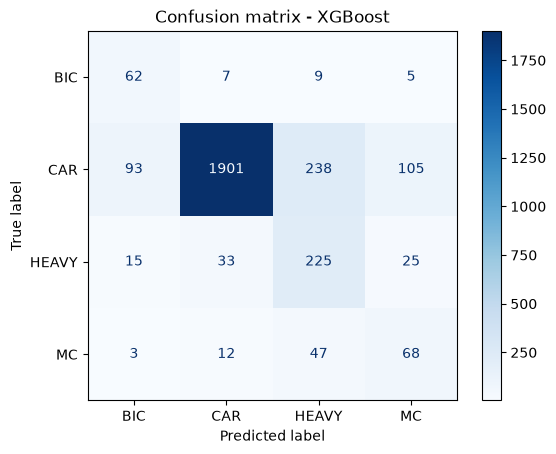

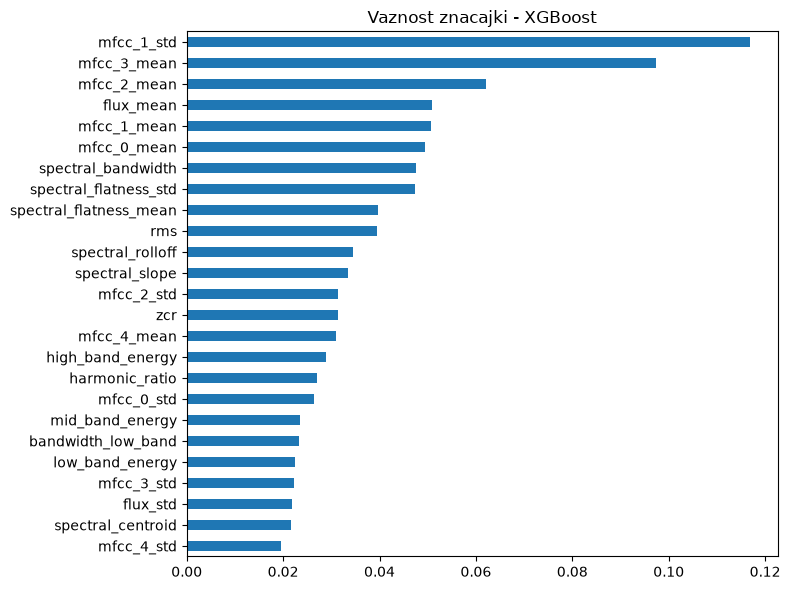

In [13]:
y_pred_enc = clf.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion matrix - XGBoost')
plt.show()

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Vaznost znacajki - XGBoost')
plt.tight_layout()
plt.show()

### Early stopping - koliko stabala je stvarno potrebno?

Umjesto nagadanja `n_estimators`, mozemo pratiti gresku na validacijskom skupu tijekom
treniranja i stati kad prestane padati - to je standardan nacin kontrole overfittinga kod
gradient boostinga (spomenuto u teoriji iznad).

Train accuracy: 0.993
Test accuracy:  0.873
Razlika (train - test): 0.120
Zaustavljeno nakon 407 stabala (od maksimalnih 1000 dopustenih)
              precision    recall  f1-score   support

         BIC       0.63      0.63      0.63        83
         CAR       0.93      0.93      0.93      2337
       HEAVY       0.59      0.66      0.62       298
          MC       0.60      0.41      0.48       130

    accuracy                           0.87      2848
   macro avg       0.69      0.66      0.67      2848
weighted avg       0.87      0.87      0.87      2848



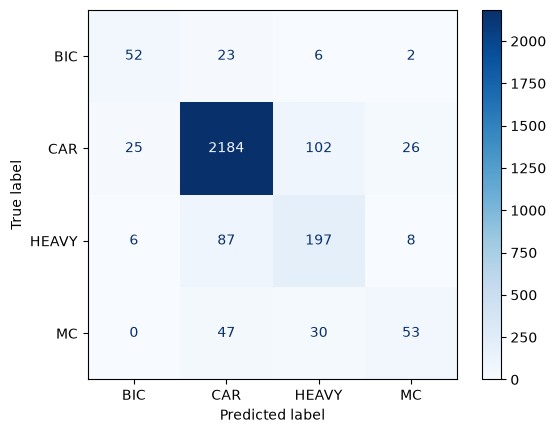

In [18]:
X_tr2, X_val, y_tr2, y_val = train_test_split(X_train, y_train_enc, test_size=0.2, stratify=y_train_enc, random_state=42)
weights_tr2 = compute_sample_weight('balanced', y_tr2)

clf_es = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)
clf_es.fit(
    X_tr2, y_tr2, sample_weight=weights_tr2,
    eval_set=[(X_val, y_val)],
    verbose=False
)

train_acc_es = clf_es.score(X_tr2, y_tr2)
test_acc_es = clf_es.score(X_test, y_test_enc)

print(f"Train accuracy: {train_acc_es:.3f}")
print(f"Test accuracy:  {test_acc_es:.3f}")
print(f"Razlika (train - test): {train_acc_es - test_acc_es:.3f}")


print(f"Zaustavljeno nakon {clf_es.best_iteration} stabala (od maksimalnih 1000 dopustenih)")

y_pred_es = le.inverse_transform(clf_es.predict(X_test))
print(classification_report(y_test, y_pred_es))

cm = confusion_matrix(y_test, y_pred_es)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.show()

## 3. Zakljucak i usporedba sva tri modela

Opce metrike:
| Model                              | Train acc | Test acc | Razlika (overfit) | Macro F1 | Weighted F1 |
|-----------------------------------|----------:|---------:|------------------:|---------:|------------:|
| Decision Tree (max depth)         | 0.813     | 0.726    | 0.087             | 0.48     | 0.76        |
| Decision Tree (no limit)          | 1.000     | 0.804    | 0.196             | 0.50     | 0.80        |
| Random Forest                     | 1.000     | 0.867    | 0.132             | 0.59     | 0.84        |
| XGBoost                           | 0.850     | 0.792    | 0.057             | 0.58     | 0.82        |
| XGBoost (early stopping)          | 0.993     | 0.870    | 0.120             | 0.67     | 0.87        |

Po klasi F1-score:
| Model                      | BIC  | CAR  | HEAVY | MC   |
|---------------------------|-----:|-----:|------:|-----:|
| Decision Tree (max depth) | 0.38 | 0.84 | 0.47  | 0.24 |
| Random Forest             | 0.56 | 0.93 | 0.48  | 0.37 |
| XGBoost                   | 0.48 | 0.89 | 0.55  | 0.41 |
| XGBoost (early stopping)  | 0.63 | 0.93 | 0.62  | 0.48 |

Po klasi recall:
| Model                      | BIC  | CAR  | HEAVY | MC   |
|---------------------------|-----:|-----:|------:|-----:|
| Decision Tree (max depth) | 0.61 | 0.76 | 0.67  | 0.35 |
| Random Forest             | 0.42 | 0.98 | 0.35  | 0.25 |
| XGBoost                   | 0.75 | 0.81 | 0.76  | 0.52 |
| XGBoost (early stopping)  | 0.63 | 0.93 | 0.66  | 0.41 |

</br>

**Zaključak:**
- Decision Tree (ograničen) --> slabiji model, ali solidan recall za manjinske klase
- Decision Tree (neograničen) --> ekstremni overfitting (train=1.0, razlika cca20%)
- Random Forest --> najbolja točnost (0.867), ali loš recall za manjinske klase
- XGBoost --> dobar balans i najmanji overfitting (0.057)

- XGBoost (early stopping) --> najbolji model ukupno:
    - najbolji test accuracy (0.87, izjednačen s RF)
    - najbolji macro-F1 (0.67)
    - značajno poboljšanje za manjinske klase (BIC, HEAVY, MC)
    - automatska kontrola overfittinga (zaustavljen na 407 stabala)
    - i dalje prisutan overfitting (razlika cca0.12), ali manji nego kod
    pojedinačnog stabla i usporediv s Random Forestom